# 01. EDA

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_PATH = Path('../data/processed/reviews_dataset.csv')
df = pd.read_csv(DATA_PATH)
class_order = ['newbie', 'casual', 'engaged', 'veteran']

In [2]:
df.head()

,appid,game,game_group,recommendationid,review,experience_class,target_playtime_hours,target_playtime_minutes,voted_up,votes_up,...,comment_count,steam_purchase,received_for_free,written_during_early_access,author_num_games_owned,author_num_reviews,review_length_chars,review_length_words,timestamp_created,created_at
0,1172470,Apex Legends,competitive,194896103,"This game is so sh*t, lobbies are so toxic, te...",newbie,23.783333,1427,False,2,...,0,True,False,False,0,6,695,134,1747247047,2025-05-14T18:24:07Z
1,1172470,Apex Legends,competitive,194921043,I've never seen a game so good ran so poorly. ...,engaged,1084.600000,65076,False,1,...,0,True,False,False,0,1,236,48,1747281454,2025-05-15T03:57:34Z
2,1172470,Apex Legends,competitive,194931313,i cant even click the continue button because ...,newbie,90.300000,5418,False,1,...,0,True,False,False,0,3,117,23,1747300511,2025-05-15T09:15:11Z
3,1172470,Apex Legends,competitive,194955247,This game is complete BS. Unbalanced matchmaki...,casual,230.700000,13842,False,2,...,0,True,False,False,44,3,996,169,1747328674,2025-05-15T17:04:34Z
4,1172470,Apex Legends,competitive,194967851,Boring game with nothing unique about it excep...,newbie,37.733333,2264,False,1,...,1,True,False,False,266,43,245,43,1747341531,2025-05-15T20:38:51Z


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467 entries, 0 to 7466
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   appid                        7467 non-null   int64  
 1   game                         7467 non-null   object 
 2   game_group                   7467 non-null   object 
 3   recommendationid             7467 non-null   int64  
 4   review                       7467 non-null   object 
 5   experience_class             7467 non-null   object 
 6   target_playtime_hours        7467 non-null   float64
 7   target_playtime_minutes      7467 non-null   int64  
 8   voted_up                     7467 non-null   bool   
 9   votes_up                     7467 non-null   int64  
 10  votes_funny                  7467 non-null   int64  
 11  weighted_vote_score          7467 non-null   float64
 12  comment_count                7467 non-null   int64  
 13  steam_purchase    

##### Базовая сводка по объёму данных, играм, классам, часам и длине отзывов

In [4]:
def subset_by_group(data, group):
    if group == 'all':
        return data.copy()
    return data[data['game_group'] == group].copy()


eda_views = {
    'all': subset_by_group(df, 'all'),
    'offline': subset_by_group(df, 'offline'),
    'competitive': subset_by_group(df, 'competitive'),
}

summary_rows = []
for group_name, group_df in eda_views.items():
    summary_rows.append({
        'game_group': group_name,
        'rows': len(group_df),
        'games': group_df['game'].nunique(),
        'classes': group_df['experience_class'].nunique(),
        'median_hours': group_df['target_playtime_hours'].median(),
        'median_words': group_df['review_length_words'].median(),
    })

pd.DataFrame(summary_rows)

,game_group,rows,games,classes,median_hours,median_words
0,all,7467,13,4,65.716667,61.0
1,offline,4086,7,4,36.225000,68.0
2,competitive,3381,6,4,381.666667,53.0


##### Баланс классов в каждом срезе

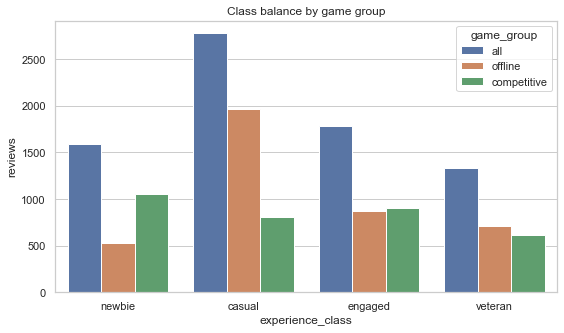

game_group,all,competitive,offline
experience_class,,,
newbie,1588,1055,533
casual,2772,808,1964
engaged,1781,907,874
veteran,1326,611,715


In [5]:
class_balance = []
for group_name, group_df in eda_views.items():
    counts = group_df['experience_class'].value_counts().reindex(class_order, fill_value=0)
    for class_name, count in counts.items():
        class_balance.append({'game_group': group_name, 'experience_class': class_name, 'reviews': count})

class_balance_df = pd.DataFrame(class_balance)
plt.figure(figsize=(9, 5))
sns.barplot(data=class_balance_df, x='experience_class', y='reviews', hue='game_group', order=class_order)
plt.title('Class balance by game group')
plt.xlabel('experience_class')
plt.ylabel('reviews')
plt.show()

class_balance_df.pivot(index='experience_class', columns='game_group', values='reviews').reindex(class_order)

##### Распределение часов игры по срезам

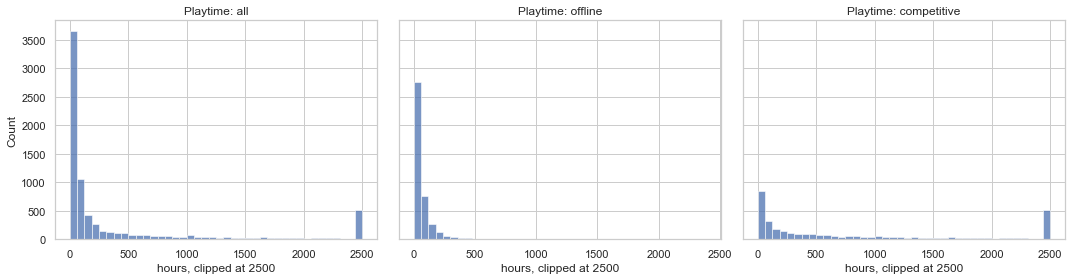

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (group_name, group_df) in zip(axes, eda_views.items()):
    sns.histplot(group_df['target_playtime_hours'].clip(upper=2500), bins=40, ax=ax)
    ax.set_title(f'Playtime: {group_name}')
    ax.set_xlabel('hours, clipped at 2500')
plt.tight_layout()
plt.show()

##### Распределение длины отзывов по классам и группам

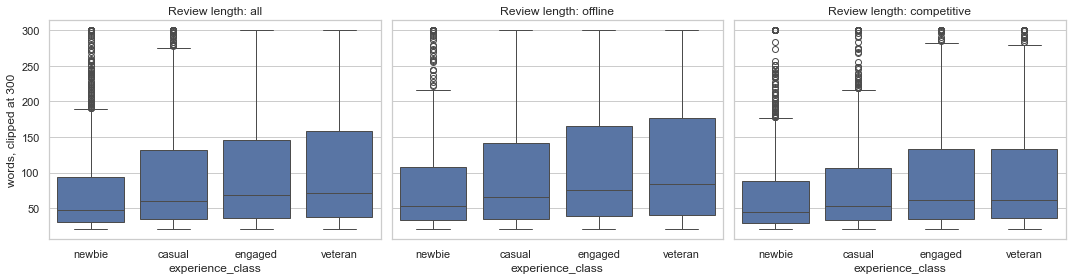

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (group_name, group_df) in zip(axes, eda_views.items()):
    sns.boxplot(
        data=group_df,
        x='experience_class',
        y=group_df['review_length_words'].clip(upper=300),
        order=class_order,
        ax=ax,
    )
    ax.set_title(f'Review length: {group_name}')
    ax.set_xlabel('experience_class')
    ax.set_ylabel('words, clipped at 300')
plt.tight_layout()
plt.show()

##### Статистика по группам и классам

In [8]:
df.groupby(['game_group', 'experience_class'], observed=False)[['target_playtime_hours', 'review_length_words']].describe()

target_playtime_hours                            \
                                             count         mean          std   
game_group  experience_class                                                   
competitive casual                           808.0   264.258148   118.127815   
            engaged                          907.0  1076.279695   412.366474   
            newbie                          1055.0    32.809747    29.341473   
            veteran                          611.0  4709.095363  3175.335285   
offline     casual                          1964.0    26.239384    11.189759   
            engaged                          874.0    70.596034    14.014329   
            newbie                           533.0     5.201188     2.820621   
            veteran                          715.0   219.237436   192.556273   

                                                                     \
                                      min          25%          50%   
game_group  experience_class                                          
competitive casual             100.216667   155.416667   242.658333   
            engaged            500.016667   729.700000  1002.033333   
            newbie               0.083333     7.691667    23.333333   
            veteran           2006.016667  2594.500000  3689.816667   
offline     casual              10.000000    16.929167    23.966667   
            engaged             50.000000    57.887500    69.375000   
            newbie               0.083333     3.050000     5.183333   
            veteran            100.100000   123.558333   159.900000   

                                                        review_length_words  \
                                      75%           max               count   
game_group  experience_class                                                  
competitive casual             364.616667    499.833333               808.0   
            engaged           1389.058333   1999.766667               907.0   
            newbie              54.050000     99.950000              1055.0   
            veteran           5558.491667  28515.533333               611.0   
offline     casual              34.866667     49.950000              1964.0   
            engaged             81.629167     99.916667               874.0   
            newbie               7.716667      9.983333               533.0   
            veteran            234.966667   2387.350000               715.0   

                                                                               \
                                    mean         std   min   25%   50%    75%   
game_group  experience_class                                                    
competitive casual             98.108911  124.259025  20.0  33.0  52.5  107.0   
            engaged           118.971334  164.216231  20.0  34.5  61.0  133.5   
            newbie             81.363033  107.188877  20.0  29.0  44.0   88.5   
            veteran           118.728314  153.375532  20.0  36.0  61.0  133.5   
offline     casual            125.337576  165.377373  20.0  35.0  66.0  142.0   
            engaged           134.376430  161.090930  20.0  39.0  75.0  165.0   
            newbie            100.795497  133.002478  20.0  33.0  53.0  108.0   
            veteran           147.888112  187.796082  20.0  40.0  84.0  177.0   

                                      
                                 max  
game_group  experience_class          
competitive casual            1054.0  
            engaged           1348.0  
            newbie            1383.0  
            veteran           1455.0  
offline     casual            1867.0  
            engaged           1272.0  
            newbie            1436.0  
            veteran           1400.0